# Spiral wave termination

In this tutorial, a disc of cardiac tissue becomes a simple model for exploring the method to stop arrhythmias. We begin with regular pacing, representing activation during sinus rhythm, then introduce a premature stimulus to provoke a rotating spiral wave: a model of reentrant electrical activity.

We then explore three attempts to end the spiral. **Ablation** changes the available path by creating a nonconducting line. A **simplified drug effect** changes how the tissue recovers between activations. Finally, a global stimulus provides an idealized **defibrillation** experiment.

## 1. Regular pacing: a model of sinus rhythm

The story begins on a circular patch of tissue, 100 mm across. The first cell shows its shape, with black surroundings outside the tissue. We will then pace its edge regularly to establish a reference for orderly propagation before introducing the spiral.


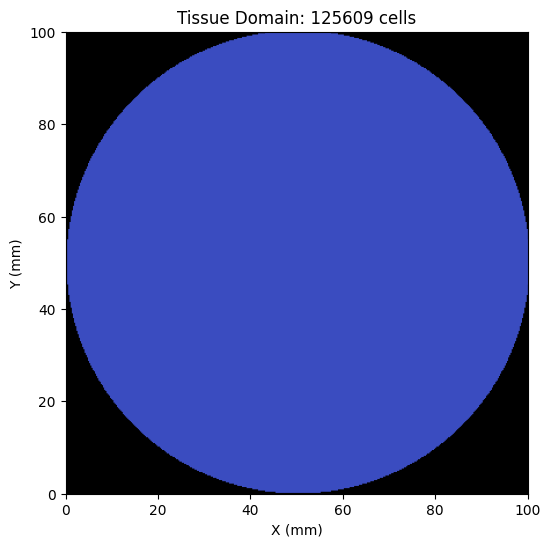

number of used grid points: 125609
total number of grid points: 160000


In [1]:
import numpy as np
import matplotlib.pyplot as plt

GRID_SIZE = 400 # 100 (mm)
DR = 0.25 # (mm)

x, y = np.meshgrid(np.arange(GRID_SIZE), np.arange(GRID_SIZE))
X, Y = x.flatten(), y.flatten()
R = np.sqrt((X - GRID_SIZE / 2) ** 2 + (Y - GRID_SIZE / 2) ** 2) 
R = R.reshape((GRID_SIZE, GRID_SIZE))
mesh = (np.abs(R) < GRID_SIZE/2).astype(int)

domain = mesh.astype(float)
domain[domain == 0] = np.nan
cmap = plt.get_cmap("coolwarm")
cmap.set_bad(color="black")

plt.figure(figsize=(6, 6))
plt.title(f"Tissue Domain: {np.count_nonzero(mesh)} cells")
plt.imshow(domain, cmap=cmap, extent=[0, 100, 0, 100], origin="lower")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.show()

print('number of used grid points:', np.sum(mesh))
print('total number of grid points:', GRID_SIZE*GRID_SIZE)

To follow the waves over time, we prepare a shared animation helper. Each experiment will leave us with a movie of the activity across the same disc.

In [2]:
from pathlib import Path
import numpy as np
from finitewave_tools.animation import Frame2DRenderer, AnimationBuilder
from IPython.display import Video, display


def write_animation(animation_name, frames, mask, nan_mask=None):
    output_dir = Path("./output")

    if not output_dir.exists():
        output_dir.mkdir(parents=True, exist_ok=True)

    frame_renderer = Frame2DRenderer()
    frame_renderer.set_frames(frames=frames)
    frame_renderer.configure_grid(np.ones((GRID_SIZE, GRID_SIZE)), upscale_factor=2)

    animation = AnimationBuilder()
    animation.frame_renderer = frame_renderer
    animation.write(
        path=output_dir,
        animation_name=animation_name,
        fps=24,
        prog_bar=True,
        clim=(0, 1),
        cmap="plasma",
        output_mask=mask,
        nan_mask=nan_mask
    )

    video_path = output_dir / f"{animation_name}.mp4"
    return video_path

We first pace the edge of the disc at regular intervals. Watch each wave travel across the tissue: this is our reference scene before introducing a premature beat.

In [3]:
from IPython.display import Video, display
import finitewave as fw


T_MAX = 1000
EXP_NAME = "sinus_on_plate"
# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([GRID_SIZE, GRID_SIZE], dr=DR)
tissue.mesh = mesh.copy()

# set up stimulation parameters:
stim_sequence = fw.StimSequence()
for t_stim in np.arange(0, T_MAX, 400):
    stim_sequence.add_stim(fw.StimCurrentCoord(time=t_stim,
                                               curr_value=100,
                                               duration=1,
                                               x_min=0, x_max=5,
                                               y_min=0, y_max=GRID_SIZE))

# create trackers
frame_tracker = fw.FrameTracker(step=300, aggregate=True)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=T_MAX, backend="jax")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.MitchellSchaeffer()
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

frames = frame_tracker.frames[:len(frame_tracker.tracking_times)]

video_path = write_animation(EXP_NAME, frames, mask=(mesh==1))

display(Video(str(video_path), embed=True, width=500))

Running MitchellSchaeffer on (400, 400) Grid:   0%|          | 0/100000 [00:00<?, ?it/s]

Building animation:   0%|          | 0/334 [00:00<?, ?it/s]

## 2. From pacing to a spiral

Now we add a premature stimulus to the pacing sequence. It reaches only part of the disc, creating an opportunity for a wave to turn around recovering tissue. The next cell prepares this S1–S2 sequence.

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw


def build_s1s2_protocol(shape, t_max, basic_cycle_length, s2_time):
    """Build a stimulation protocol to induce reentry in a tissue.
    The protocol consists of a series of S1 stimuli followed by a single S2 stimulus."""
    stim_sequence = fw.StimSequence()
    for t_stim in range(0, t_max, basic_cycle_length):
        stim_sequence.add_stim(fw.StimCurrentCoord(time=t_stim,
                                                   curr_value=100,
                                                   duration=2,
                                                   x_min=1, x_max=5,
                                                   y_min=1, y_max=shape[1]))

    stim_sequence.add_stim(fw.StimCurrentCoord(time=s2_time,
                                               curr_value=100,
                                               duration=2,
                                               x_min=0, x_max=shape[0]//2,
                                               y_min=0 , y_max=shape[1]//2 ))
    return stim_sequence

We now run the premature-stimulation experiment. Follow the wave after the second stimulus and look for a curling front that continues to rotate, rather than simply leaving the disc.

In [5]:
T_MAX = 1500
EXP_NAME = "spiral_on_plate"

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, T_MAX, basic_cycle_length=600, s2_time=350)

# create a tissue of size 256x256 with cardiomycytes:
tissue = fw.CardiacTissue([GRID_SIZE, GRID_SIZE], dr=DR)
tissue.mesh = mesh.copy()

# create trackers
frame_tracker = fw.FrameTracker(step=300, aggregate=True)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=T_MAX, backend="jax")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.MitchellSchaeffer()
simulation.stim_sequence = s1_s2_protocol
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

frames = frame_tracker.frames[:len(frame_tracker.tracking_times)]

video_path = write_animation(EXP_NAME, frames, mask=(mesh==1))

display(Video(str(video_path), embed=True, width=500))

Running MitchellSchaeffer on (400, 400) Grid:   0%|          | 0/150000 [00:00<?, ?it/s]

Building animation:   0%|          | 0/501 [00:00<?, ?it/s]

## 3. Interrupting the path with ablation

For this experiment, the disc contains a nonconducting obstacle. At 800 ms, we add a narrow ablation line between that obstacle and the tissue boundary, aiming to interrupt the route available to the rotating wave. Watch how the activity changes after the line appears.

`Command` is particularly useful for implementing custom interventions: it lets us introduce a change at a chosen moment while the simulation is running. Here, it provides the timed ablation intervention.

In [6]:
class Ablate(fw.Command):
    def __init__(self, time, x_min, x_max, y_min, y_max):
        super().__init__(time=time)
        self.x_min = x_min
        self.x_max = x_max
        self.y_min = y_min
        self.y_max = y_max

    def build_ablation_area(self, simulation):
        tissue_mask = simulation.cardiac_tissue.mesh > 0
        ablation_mask = np.zeros_like(simulation.cardiac_tissue.mesh, dtype=bool)
        ablation_mask[self.x_min:self.x_max, self.y_min:self.y_max] = True
        ablation_mask &= tissue_mask
        ablation_ids = np.where(ablation_mask[tissue_mask])[0]
        ablation_ids = simulation.backend.wrap_indexes(ablation_ids)
        return ablation_mask, ablation_ids

    def execute(self, simulation):
        print(f"Ablating tissue at time {self.t} ms")
        mask, ids = self.build_ablation_area(simulation)
        simulation.cardiac_tissue.mesh[mask] = 2
        simulation.spatial_discretization.update_weights()
        simulation.time_integration.assemble_system()
        simulation.cardiac_model._u = simulation.backend.set_flat_values(
            simulation.cardiac_model._u, ids, np.nan)
        simulation.time_integration.u = simulation.backend.set_flat_values(
            simulation.time_integration.u, ids, np.nan)
        simulation.time_integration.u_old = simulation.backend.set_flat_values(
            simulation.time_integration.u_old, ids, np.nan)


T_MAX = 1500
EXP_NAME = "ablation_on_plate"

tissue_ablated = fw.CardiacTissue([GRID_SIZE, GRID_SIZE], dr=DR)
tissue_ablated.mesh[mesh == 0] = 0
tissue_ablated.mesh[180:220, 100:240] = 2
fibro_mask = (tissue_ablated.mesh == 2)

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, T_MAX, basic_cycle_length=600, s2_time=350)

# create trackers
frame_tracker = fw.FrameTracker(step=300, aggregate=True)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=T_MAX, backend="jax")
simulation.cardiac_tissue = tissue_ablated
simulation.cardiac_model = fw.MitchellSchaeffer()
# add the tissue and the stim parameters to the model object:
simulation.stim_sequence = s1_s2_protocol
simulation.tracker_sequence = tracker_sequence
simulation.command_sequence = fw.CommandSequence()
simulation.command_sequence.add_command(Ablate(time=800, x_min=195, x_max=205,
                                               y_min=0, y_max=100))

# run the model:
simulation.run()

frames = frame_tracker.frames[:len(frame_tracker.tracking_times)]

video_path = write_animation(EXP_NAME, frames, mask=(mesh>0), nan_mask=fibro_mask)

display(Video(str(video_path), embed=True, width=500))

Running MitchellSchaeffer on (400, 400) Grid:   0%|          | 0/150000 [00:00<?, ?it/s]

Ablating tissue at time 800 ms


Building animation:   0%|          | 0/501 [00:00<?, ?it/s]

## 4. Changing the recovery time

Instead of changing the wave's path, we next change the tissue's recovery. Before returning to the disc, we compare action potentials in a short strand of tissue. The curves show what happens as we increase a time scale controlling repolarization in the Mitchell–Schaeffer model.

Running MitchellSchaeffer on (100, 1) Grid:   0%|          | 0/80000 [00:00<?, ?it/s]

Running MitchellSchaeffer on (100, 1) Grid:   0%|          | 0/80000 [00:00<?, ?it/s]

Running MitchellSchaeffer on (100, 1) Grid:   0%|          | 0/80000 [00:00<?, ?it/s]

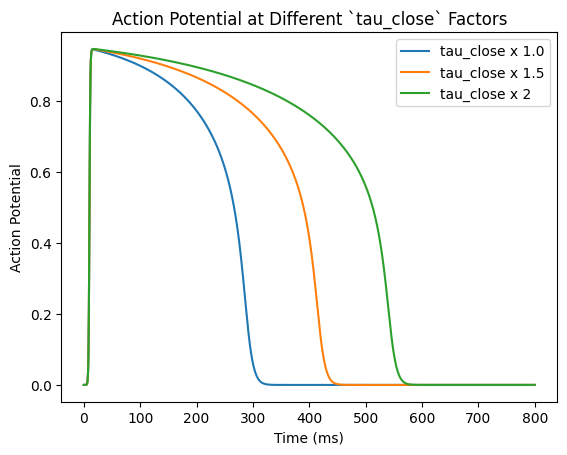

In [11]:
T_MAX = 800

def run_sinus_on_line(tau_factor=1.):
    # create a tissue plate
    tissue = fw.CardiacTissue([100, 1], dr=DR)

    act_pot_tracker = fw.ActionPotentialTracker(node_inds=[50, 0], step=10)
    tracker_sequence = fw.TrackerSequence()
    tracker_sequence.add_tracker(act_pot_tracker)

    # create model object and set up parameters:
    simulation = fw.CardiacSimulation(dt=0.01, t_max=T_MAX, backend="jax")
    simulation.cardiac_tissue = tissue
    simulation.cardiac_model = fw.MitchellSchaeffer()
    simulation.cardiac_model.tau_close *= tau_factor
    # add the tissue and the stim parameters to the model object:
    simulation.stim_sequence = fw.StimSequence()
    simulation.stim_sequence.add_stim(fw.StimCurrentCoord(time=0,
                                                        curr_value=100,
                                                        duration=1,
                                                        x_min=0, x_max=5,
                                                        y_min=0, y_max=1))
    simulation.tracker_sequence = tracker_sequence

    # run the model:
    simulation.run()

    return act_pot_tracker.tracking_times, act_pot_tracker.output


for tau_factor in [1.0, 1.5, 2]:
    times, output = run_sinus_on_line(tau_factor=tau_factor)
    plt.plot(times, output, label=f"tau_close x {tau_factor}")
plt.xlabel("Time (ms)")
plt.ylabel("Action Potential")
plt.title(r"Action Potential at Different `tau_close` Factors")
plt.legend()
plt.show()

Back on the disc, we apply the same idea at 800 ms, doubling the repolarization time scale during the run. This represents a simplified drug effect within the model. A custom `Command` schedules the intervention; the animation lets us examine how the spiral responds as recovery changes.

In [8]:
class ApplyDrug(fw.Command):
    """ Class to represent a drug effect command that modifies the tau_close
    parameter of the Mitchell-Schaeffer model at a specific time.

    E.g., I_Kr decrease yields slower repolarization,
    which corresponds to a longer time constant tau in the MS model:
    """
    def __init__(self, time, tau_factor):
        super().__init__(time)
        self.tau_factor = tau_factor

    def execute(self, simulation):
        simulation.cardiac_model.tau_close *= self.tau_factor


EXP_NAME = "drugs_on_plate"
T_MAX = 2000
T_DRUG = 800

# set up a command sequence to apply the drug effect at a specific time
command_sequence = fw.CommandSequence()
command_sequence.add_command(ApplyDrug(T_DRUG, tau_factor=2.0))

# create a tissue plate
tissue = fw.CardiacTissue([GRID_SIZE, GRID_SIZE], dr=DR)
tissue.mesh[mesh == 0] = 0

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, T_MAX, basic_cycle_length=600, s2_time=350)

# create trackers
frame_tracker = fw.FrameTracker(step=300, aggregate=True)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=T_MAX, backend="jax")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.MitchellSchaeffer()
# add the tissue and the stim parameters to the model object:
simulation.stim_sequence = s1_s2_protocol
simulation.tracker_sequence = tracker_sequence
simulation.command_sequence = command_sequence

# run the model:
simulation.run()

frames = frame_tracker.frames[:len(frame_tracker.tracking_times)]

video_path = write_animation(EXP_NAME, frames, mask=(mesh>0))

display(Video(str(video_path), embed=True, width=500))

Running MitchellSchaeffer on (400, 400) Grid:   0%|          | 0/200000 [00:00<?, ?it/s]

Building animation:   0%|          | 0/667 [00:00<?, ?it/s]

## 5. A global stimulus

Finally, we return to the disc and apply a stimulus across the whole tissue at 800 ms. This is a simplified defibrillation experiment: a simultaneous excitation attempts to interrupt the existing spiral. Watch the remaining activity and the response to later pacing to assess whether rotation persists.

Together, these experiments explore three different ways to disturb reentry: change its path, change tissue recovery, or excite the tissue at once.

In [9]:
EXP_NAME = "defib_on_plate"
T_MAX = 1300
T_DEFIB = 800

# create a tissue plate
tissue = fw.CardiacTissue([GRID_SIZE, GRID_SIZE], dr=DR)
tissue.mesh[mesh == 0] = 0

# set up stimulation protocol:
s1_s2_protocol = build_s1s2_protocol(mesh.shape, T_MAX, basic_cycle_length=600, s2_time=350)
s1_s2_protocol.add_stim(fw.StimVoltageCoord(time=T_DEFIB, volt_value=1,
                                            x_min=0, x_max=GRID_SIZE,
                                            y_min=0, y_max=GRID_SIZE ))
# create trackers
frame_tracker = fw.FrameTracker(step=300, aggregate=True)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=T_MAX, backend="jax")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.MitchellSchaeffer()
# add the tissue and the stim parameters to the model object:
simulation.stim_sequence = s1_s2_protocol
simulation.tracker_sequence = tracker_sequence

# run the model:
simulation.run()

frames = frame_tracker.frames[:len(frame_tracker.tracking_times)]

video_path = write_animation(EXP_NAME, frames, mask=(mesh>0))

display(Video(str(video_path), embed=True, width=500))

Running MitchellSchaeffer on (400, 400) Grid:   0%|          | 0/130000 [00:00<?, ?it/s]

Building animation:   0%|          | 0/434 [00:00<?, ?it/s]